In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('C:/Users/Admin/Downloads/transactions_.csv')
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,net_change_org,net_change_dest,ratio_amount_orig,ratio_amount_dest,orig_zero_after,dest_zero_after
0,8,158007,0,0,474016,1618631,0,0,1144615,15800711999,0,1,0
1,236,457948,0,0,2720411,3178359,0,0,457948,45794829999,0,1,0
2,37,153602,11160428,11314031,3274930,3121327,0,153603,-153603,0,0,0,0
3,331,49555,10865,0,0,49555,0,-10865,49555,4,4955514000,1,0
4,250,29648,0,0,56933,86581,0,0,29648,2964802000,0,1,0


```
Bivariate Analysis Using Two Variables (Numerical vs Numerical)...

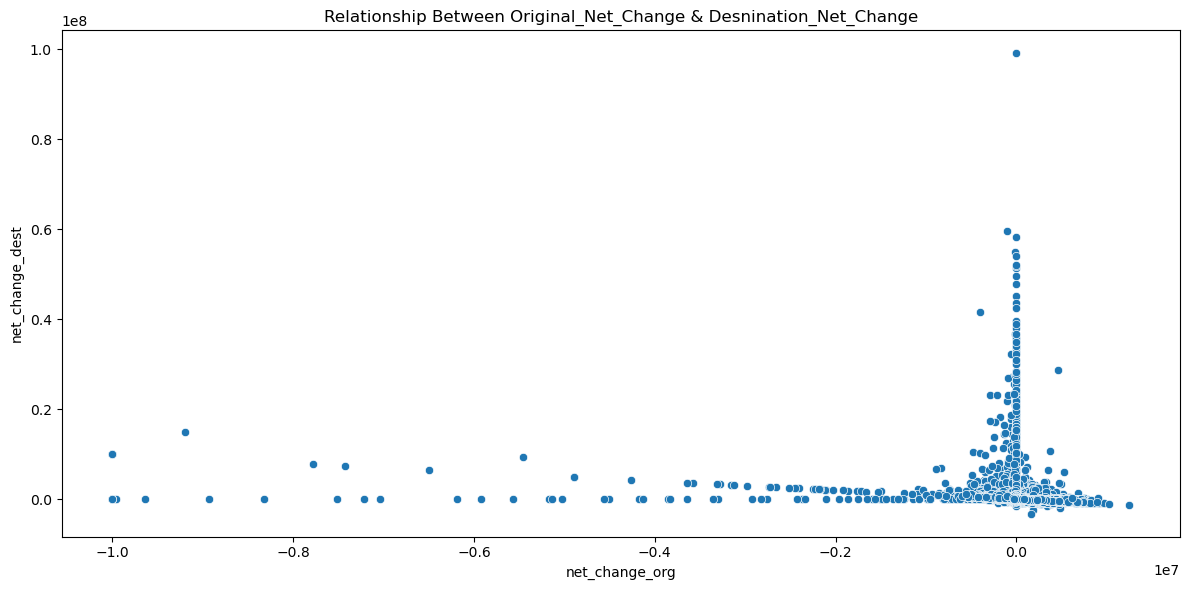

In [2]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='net_change_org', y='net_change_dest')
plt.title('Relationship Between Original_Net_Change & Desnination_Net_Change')
plt.tight_layout()
plt.show()

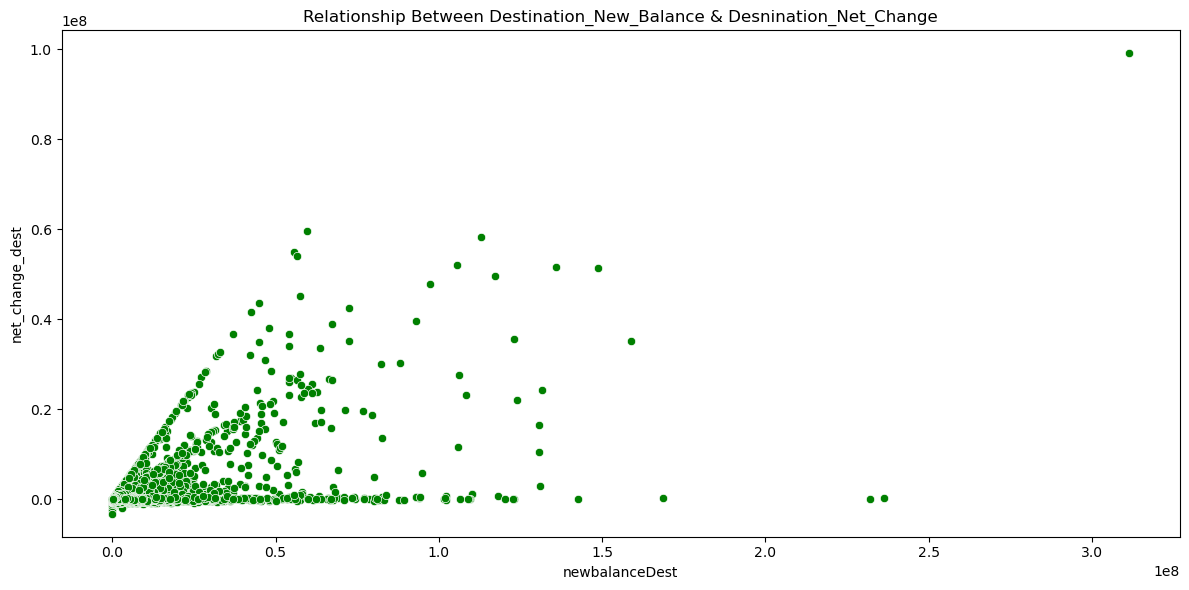

In [3]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='newbalanceDest', y='net_change_dest', color='green')
plt.title('Relationship Between Destination_New_Balance & Desnination_Net_Change')
plt.tight_layout()
plt.show()

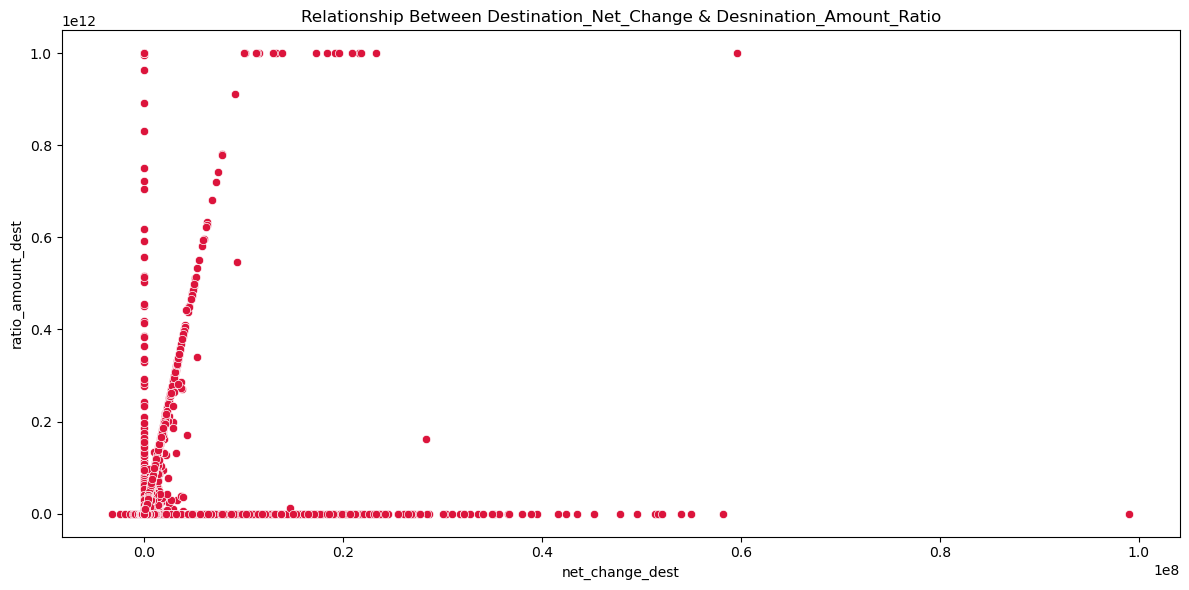

In [4]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='net_change_dest', y='ratio_amount_dest', color='crimson')
plt.title('Relationship Between Destination_Net_Change & Desnination_Amount_Ratio')
plt.tight_layout()
plt.show()

```
Creating Crosstabs for Categorical Features (Categorical vs Categorical)...

In [5]:
pd.crosstab(index=df['isFraud'], columns=df['orig_zero_after'])

orig_zero_after,0,1
isFraud,,
0,86486,113231
1,5,277


In [6]:
pd.crosstab(index=df['isFraud'], columns=df['dest_zero_after'])

dest_zero_after,0,1
isFraud,,
0,123293,76424
1,132,150


```
Creating Pivot Tables for Bivariate Analysis(Categorical vs Numerical)...

In [7]:
pd.pivot_table(df, values=df.drop(columns=['isFraud', 'orig_zero_after', 'dest_zero_after']).columns.tolist(), index='isFraud', aggfunc='mean')

,amount,net_change_dest,net_change_org,newbalanceDest,newbalanceOrig,oldbalanceDest,oldbalanceOrg,ratio_amount_dest,ratio_amount_orig,step
isFraud,,,,,,,,,,
0,1.783446e+05,124491.144339,2.307866e+04,1.218996e+06,853125.622351,1.094505e+06,8.300471e+05,2.674617e+09,7.110056e+09,243.104563
1,1.524029e+06,656987.078014,-1.524029e+06,1.140978e+06,291063.053191,4.839906e+05,1.815092e+06,1.131410e+11,0.000000e+00,374.503546


In [8]:
pd.pivot_table(df, values=df.drop(columns=['isFraud', 'orig_zero_after', 'dest_zero_after']).columns.tolist(), index='isFraud', aggfunc='min')

,amount,net_change_dest,net_change_org,newbalanceDest,newbalanceOrig,oldbalanceDest,oldbalanceOrg,ratio_amount_dest,ratio_amount_orig,step
isFraud,,,,,,,,,,
0,0,-3228631,-1495505,0,0,0,0,0,0,1
1,0,0,-10000000,0,0,0,0,0,0,2


In [9]:
pd.pivot_table(df, values=df.drop(columns=['isFraud', 'orig_zero_after', 'dest_zero_after']).columns.tolist(), index='isFraud', aggfunc='max')

,amount,net_change_dest,net_change_org,newbalanceDest,newbalanceOrig,oldbalanceDest,oldbalanceOrg,ratio_amount_dest,ratio_amount_orig,step
isFraud,,,,,,,,,,
0,52042803,99045450,1247922,311404901,35017380,235932693,35002864,999999999999,5204280346999,718
1,10000000,14915111,0,17213556,40399045,16606636,50399045,999999999999,0,741


```
Bivariate Analysis Using bar chart (Median)...

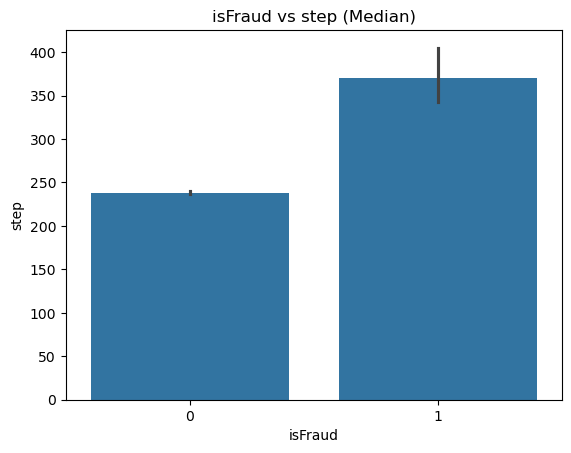

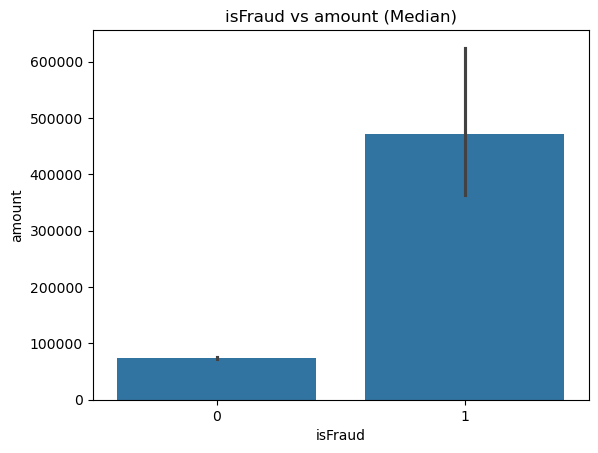

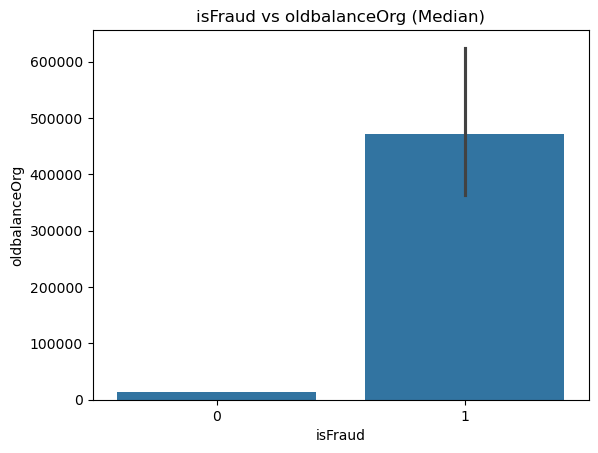

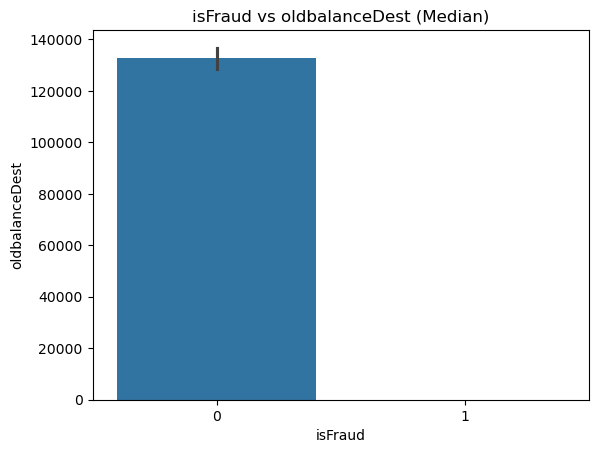

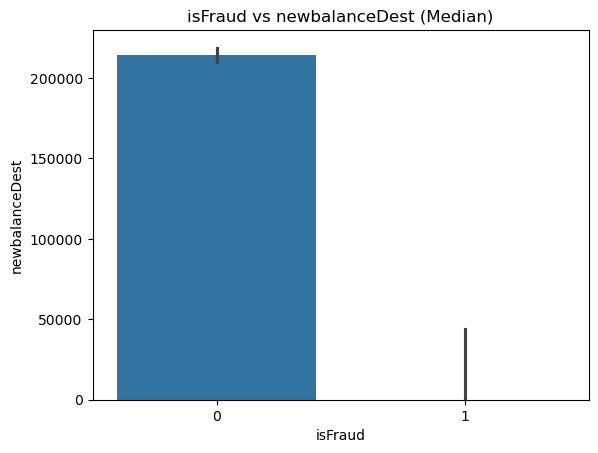

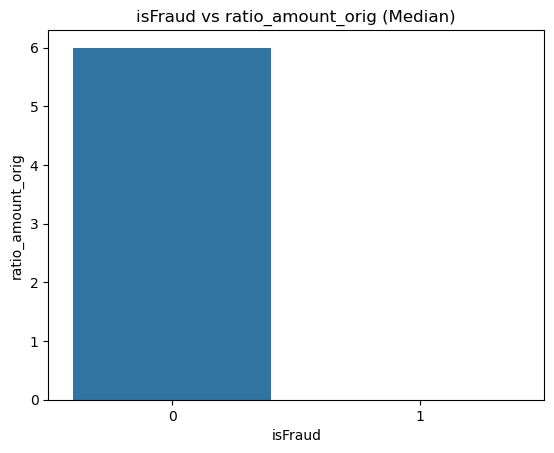

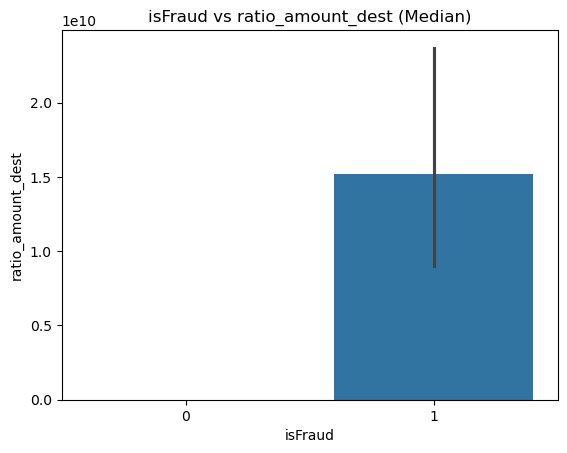

In [10]:
pd.pivot_table(df, values=df.drop(columns=['isFraud', 'orig_zero_after', 'dest_zero_after']).columns.tolist(), index='isFraud', aggfunc='sum')

cols = df.drop(columns=['isFraud', 'orig_zero_after', 'dest_zero_after', 'newbalanceOrig', 'net_change_org', 'net_change_dest']).columns.tolist()
for col in cols:
    print()
    sns.barplot(data=df, x='isFraud', y=col, estimator='median')
    plt.title(f'isFraud vs {col} (Median)')
    plt.show()

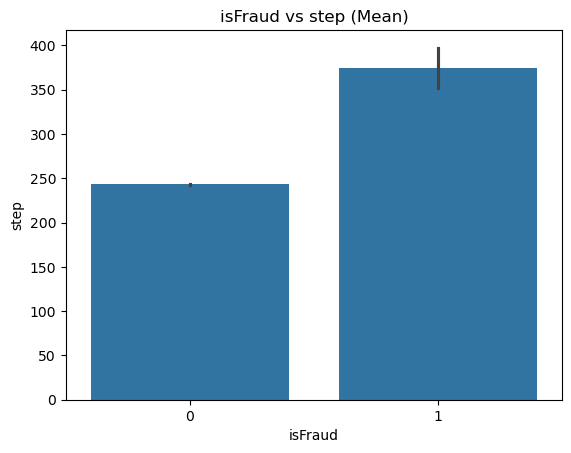

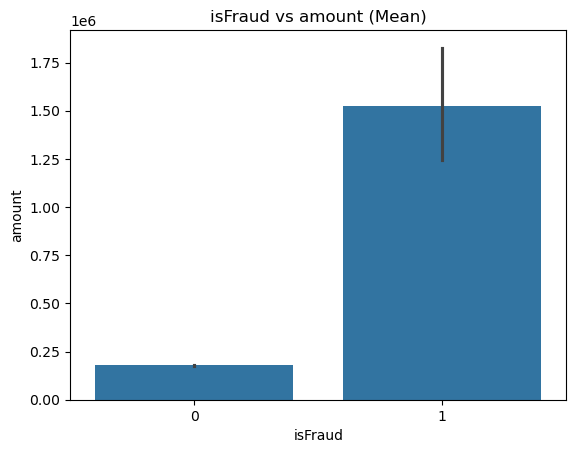

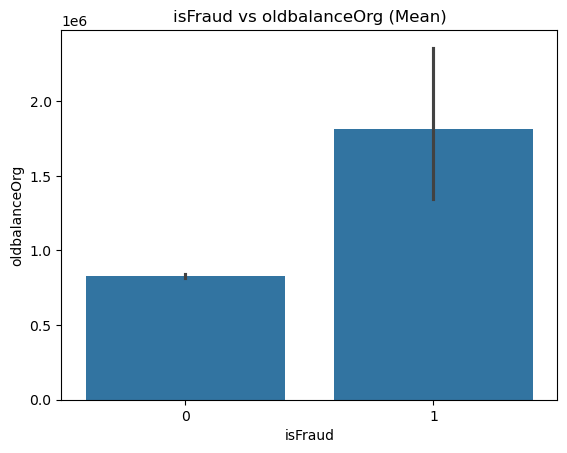

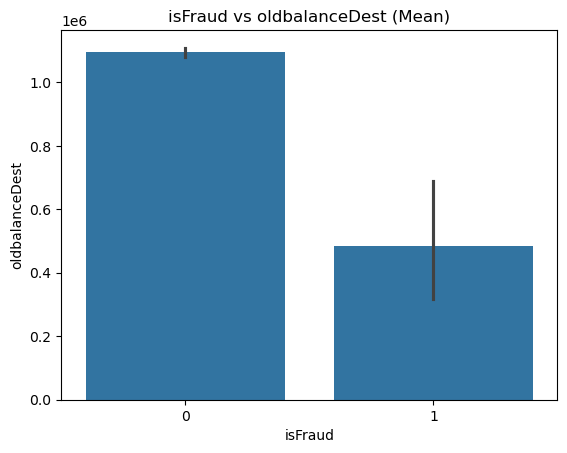

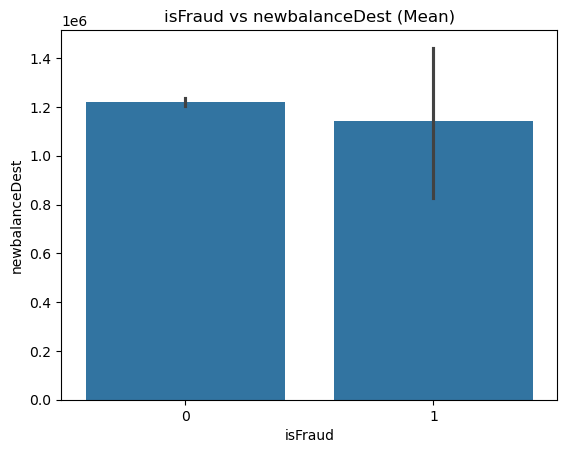

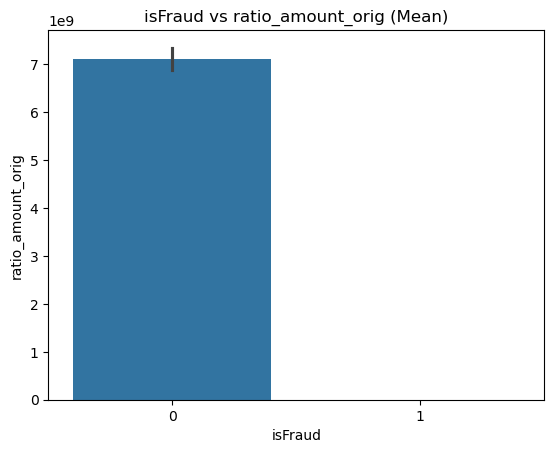

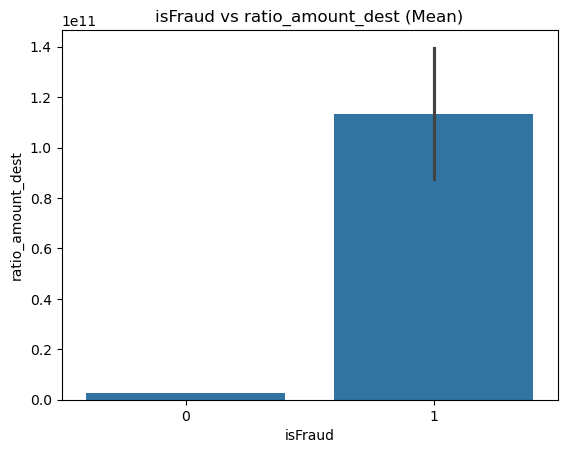

In [11]:
pd.pivot_table(df, values=df.drop(columns=['isFraud', 'orig_zero_after', 'dest_zero_after']).columns.tolist(), index='isFraud', aggfunc='sum')

cols = df.drop(columns=['isFraud', 'orig_zero_after', 'dest_zero_after', 'newbalanceOrig', 'net_change_org', 'net_change_dest']).columns.tolist()
for col in cols:
    print()
    sns.barplot(data=df, x='isFraud', y=col, estimator='mean')
    plt.title(f'isFraud vs {col} (Mean)')
    plt.show()

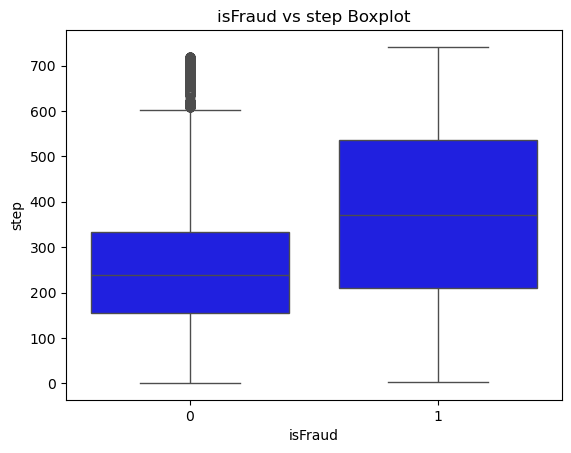

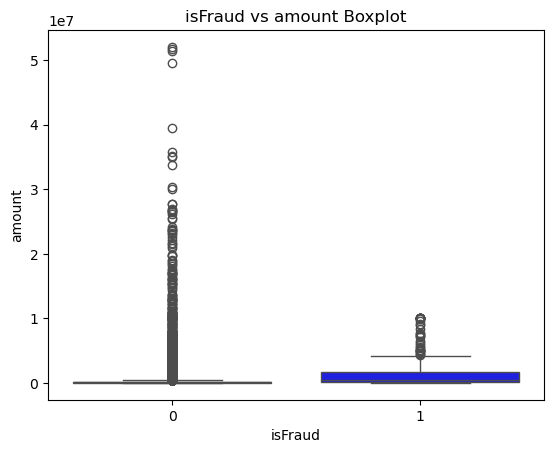

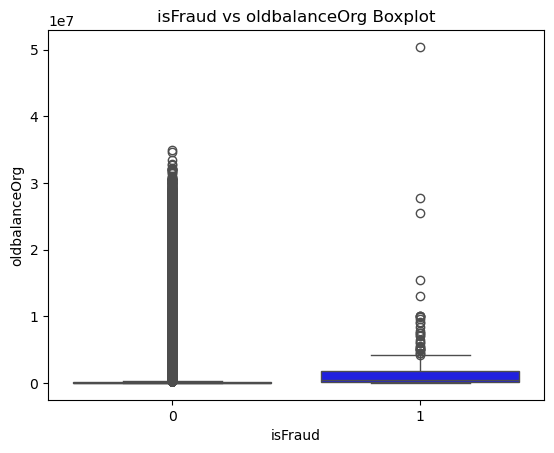

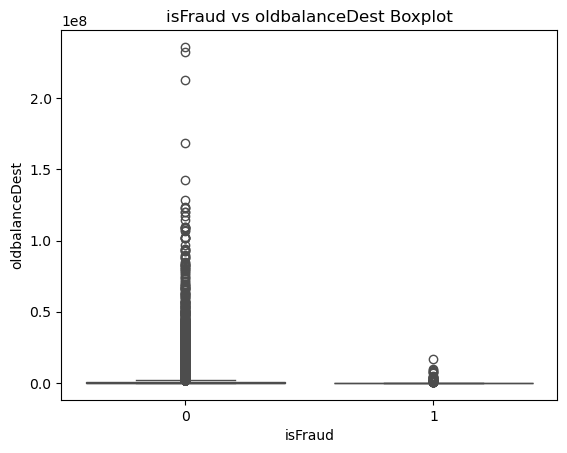

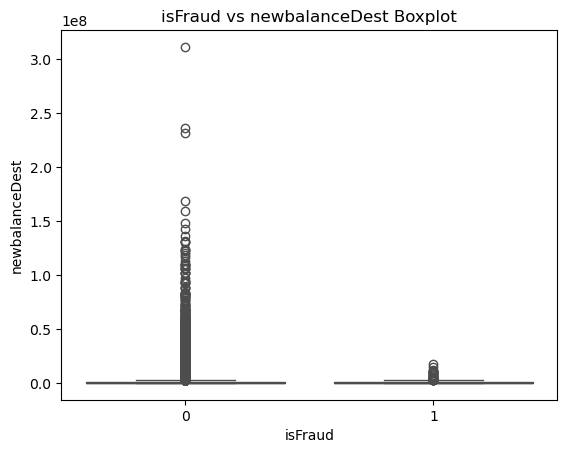

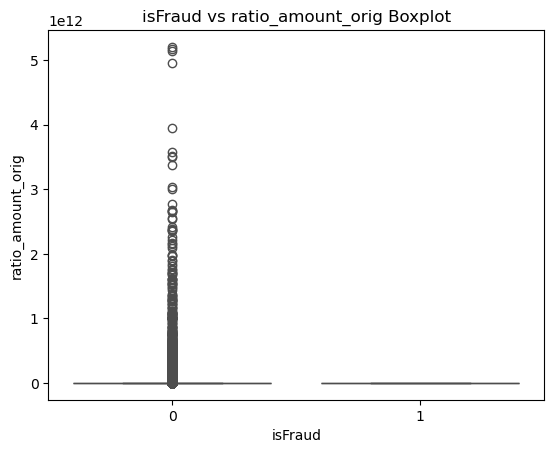

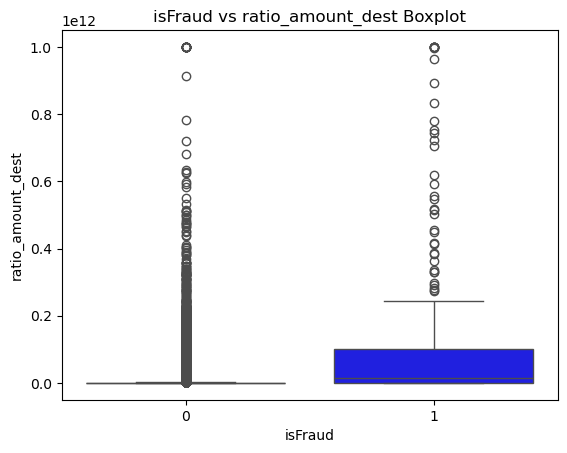

In [12]:
pd.pivot_table(df, values=df.drop(columns=['isFraud', 'orig_zero_after', 'dest_zero_after']).columns.tolist(), index='isFraud', aggfunc='sum')

cols = df.drop(columns=['isFraud', 'orig_zero_after', 'dest_zero_after', 'newbalanceOrig', 'net_change_org', 'net_change_dest']).columns.tolist()
for col in cols:
    print()
    sns.boxplot(data=df, x='isFraud', y=col, color='blue')
    plt.title(f'isFraud vs {col} Boxplot')
    plt.show()

```
It's generally not useful here to use histogram for this imbalanced dataset. because one category will extemely dominate the other.
For example, see bwlow!

<Axes: xlabel='ratio_amount_orig', ylabel='Count'>

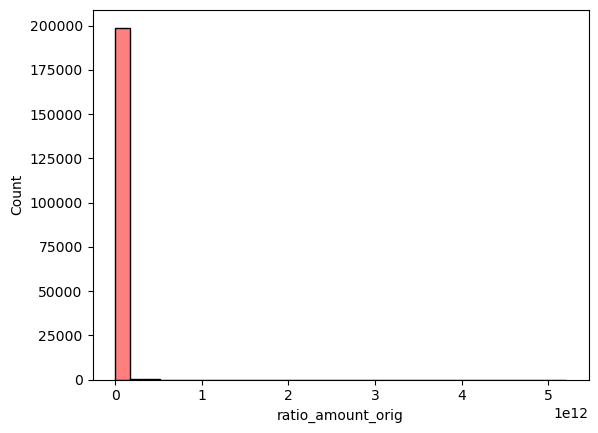

In [13]:
non_fraud_data = df.loc[df['isFraud'] == 0, :]
fraud_data = df.loc[df['isFraud'] == 1, :]

sns.histplot(data=fraud_data, x='ratio_amount_orig', bins=30, alpha=0.5, color='blue')
sns.histplot(data=non_fraud_data, x='ratio_amount_orig', bins=30, alpha=0.5, color='red')

The target feature is too imbalanced that it's 'non-fraud data' dominatiing the whole histogram.

```
Correlaion of features...